In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

from AI4AO import ZernikeWFS, DeformableMirror, imshow

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [2]:
imat_data = np.load(r"../Data/Oziriis/IM_fullframe.npy")
imat_data = torch.from_numpy(imat_data).to(device = device, dtype = torch.float32)

C,W,H = imat_data.shape
pad = int(W - H) // 2
imat_data = torch.nn.functional.pad(imat_data, (pad, pad, 0, 0))

M2C = np.load(r"../Data/Oziriis/M2C_KL.npy")
M2C = torch.from_numpy(M2C).to(device = device, dtype = torch.float32)

reference_frame = np.load(r"../Data/Oziriis/reference_intensity.npy")[3:-3]
reference_frame = torch.from_numpy(reference_frame).to(device = device, dtype = torch.float32)
reference_frame /= reference_frame.sum()
reference_frame = torch.nn.functional.pad(reference_frame, (pad+1, pad+1, 0, 0))

binnary_reference = imat_data.std(dim = 0)
binnary_reference = (binnary_reference > binnary_reference.max() * 0.056).to(device=device, dtype = torch.float32)
binnary_reference /= binnary_reference.sum()

In [3]:
WFSParams = {"Nres":90,
             "sampling":250/90,
             "D": 0.6,
             "useNoise": False,
             "MaskType": "DoubleZernike",
             "beamSplitProportionForWFSDetector": 0,
             "Nactuator": 11,
             "Wavelength": 1550e-9,
             "Use_MTF": False,
             "MTF_upscale": 10,
             }

wfs = ZernikeWFS(WFSParams, device)

c:\Users\foyarzun\AOvenv\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4217.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


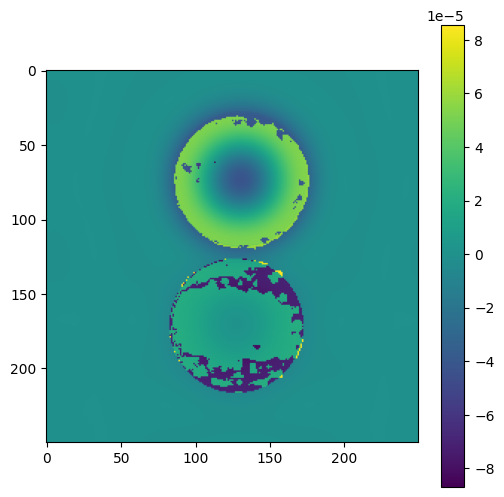

In [4]:
"""
Trains the MaskGenerator neural network to match a target mask pattern.
Generates live plots and saves intermediate mask states into a GIF.

Args:
    maskGenerator (nn.Module): Neural network to generate the mask.
    uv_coords (Tensor): 2D coordinates input to the mask generator.
    mask (Tensor): Target mask used for loss computation.
    loss (function): Loss function to optimize.
    TrainRunNb (int): Number of training iterations.
    optimizer (torch.optim.Optimizer): Optimizer used for training.
    device (str): Device for computation.

Returns:
    None
"""
final_train_loss = 0

TrainRunNb = 300
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(binnary_reference.cpu().detach().numpy())
fig.colorbar(img)
plt.show()

optimizer = torch.optim.AdamW([wfs.positions], 5e-3, fused = True)
wfs.train()

for u in range(0,TrainRunNb) :
    

    optimizer.zero_grad()
    
    wfs.BuildMask()

    wfs.BuildReferenceIntensity() 

    digital_image = wfs.reference_intensity
    

    l = loss(binnary_reference * 1e5,digital_image * 1e5)

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((binnary_reference - digital_image).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



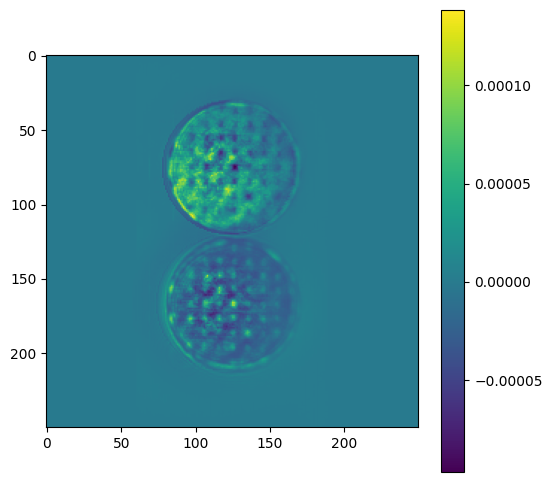

In [ ]:
"""
Trains the MaskGenerator neural network to match a target mask pattern.
Generates live plots and saves intermediate mask states into a GIF.

Args:
    maskGenerator (nn.Module): Neural network to generate the mask.
    uv_coords (Tensor): 2D coordinates input to the mask generator.
    mask (Tensor): Target mask used for loss computation.
    loss (function): Loss function to optimize.
    TrainRunNb (int): Number of training iterations.
    optimizer (torch.optim.Optimizer): Optimizer used for training.
    device (str): Device for computation.

Returns:
    None
"""

with torch.no_grad():
    wfs.depths[:] = torch.tensor(
        [torch.pi * 0.76, -torch.pi * 0.33],
        device=wfs.depths.device
    )

final_train_loss = 0

TrainRunNb = 300
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(reference_frame.cpu().detach().numpy())
fig.colorbar(img)
plt.show()

optimizer = torch.optim.AdamW([wfs.depths, wfs.diameters], 5e-3, fused = True)
wfs.train()

for u in range(0,TrainRunNb) :
    

    optimizer.zero_grad()
    
    wfs.BuildMask()

    wfs.BuildReferenceIntensity() 

    digital_image = wfs.reference_intensity
    

    l = loss(reference_frame * 1e5,digital_image * 1e5)

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((reference_frame - digital_image).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



In [4]:
DMParams = {"moffatParam":2,
            "signedAmplitude": -8e-6,
            "MechCoupling": 0.36, 
            "FlipLeftRight": True,
            "FlipTopBottom": True}

param = {}
param['rotationAngle'] = 90
# shift X in m
param['shiftX'] = 0
# shift Y in m
param['shiftY'] = 0
# amamorphosis angle in degrees
param['anamorphosisAngle'] = 0
# normal scaling in % of diameter
param['tangentialScaling'] = 0
# radial scaling in % of diameter
param['radialScaling'] = 0

dm = DeformableMirror(WFSParams,
                    DMParams,
                    device=device,
                    offset_to_fit_number_of_actuators=0.1,
                    misreg=param)


with torch.no_grad():
    wfs.depths[:] = torch.tensor(
        [torch.pi * 0.76, -torch.pi * 0.33],
        device=wfs.depths.device
    )
wfs.BuildMask()

wfs.BuildReferenceIntensity()
dm.RoughCalibration(wfs, imat_data, M2C)

Best configuration found to be: 
Rotation angle: 90.0
Sign: Negative
Flip left-right: True
Flip top-bottom: True

Updating values in the DM


In [10]:
ref_phase = torch.nn.Parameter(torch.zeros(*wfs.pupil.shape, device = device, dtype = torch.float32))
ref_pupil = torch.nn.Parameter(torch.ones(*wfs.pupil.shape, device = device, dtype = torch.float32))

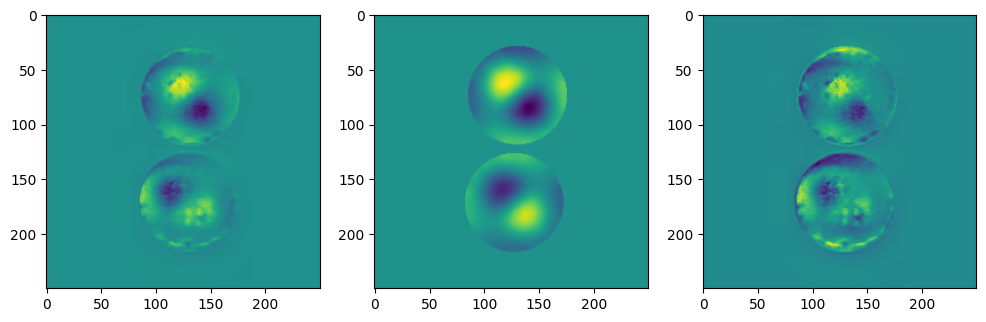

In [11]:
index = list(range(2,80,1))
target = imat_data[index]

dm.modesComputation()
modes = dm.GetModalModes(M2C[:,index])
amp = 1e-2

wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)
digital_image = wfs.iMat

idx = 6
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(target[idx].cpu().numpy())

plt.subplot(132)
plt.imshow(digital_image[idx].cpu().detach().numpy())

plt.subplot(133)
plt.imshow((target - digital_image)[idx].cpu().detach().numpy())

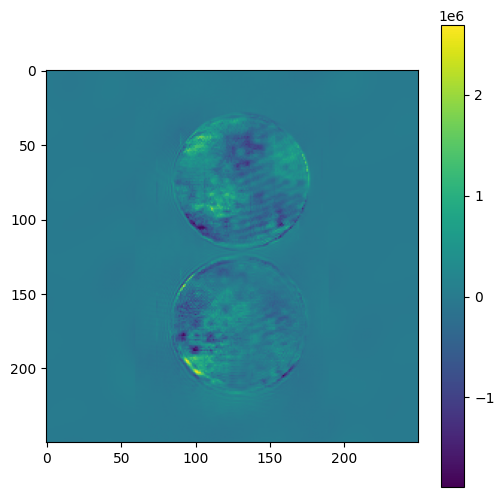

########################################
loss = 0.00252
########################################
({'rotationAngle': 91.21277618408203, 'shiftX': 0.006359059810638428, 'shiftY': -0.006218476692835489, 'anamorphosisAngle': -154.5662384033203, 'tangentialScaling': 8.214648813009262, 'radialScaling': 7.4726782739162445}, {'moffatParam': 0.9366011619567871, 'signedAmplitude': -1.4887010365782771e-05, 'MechCoupling': 0.197491854429245, 'FlipLeftRight': True, 'FlipTopBottom': True})


In [40]:
TrainRunNb = 200

loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))

img = ax.imshow(target[4].cpu().detach().numpy())
fig.colorbar(img)

original_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
original_positons = dm.rotate_coordinates(original_positons)


warmup_iters = TrainRunNb // 2
lr_start = -10
lr_end = -2

optimizer = torch.optim.AdamW(  [{"params": dm.parameters(), "lr": 1e-2},
                                {"params": [ref_phase, ref_pupil], "lr": 10**lr_start},
                                {"params": wfs.parameters(), "lr": 1e-3}],
                                fused=True
                                )


wfs.reference_intensity = None

for u in range(0,TrainRunNb) :

    if u < warmup_iters:
        alpha = u / warmup_iters
        optimizer.param_groups[1]["lr"] = 10**(
            lr_start + alpha * (lr_end - lr_start)
        )
    if u == warmup_iters:
        optimizer.param_groups[1]["lr"] = 10**lr_end
    
    optimizer.zero_grad()

    wfs.BuildMask()
    
    modes = dm(M2C[:,index])

    wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

    digital_image = wfs.iMat
    
    l = ((target - digital_image)**2).sum()

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((target - digital_image)[4].cpu().detach().numpy()*1e10)
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.5)

        print("#"*40)
        print(f'loss = {l.item():.5f}')
        print("#"*40)
    
print(dm.GetMisreg())

transformed_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
transformed_positons = dm.rotate_coordinates(transformed_positons)

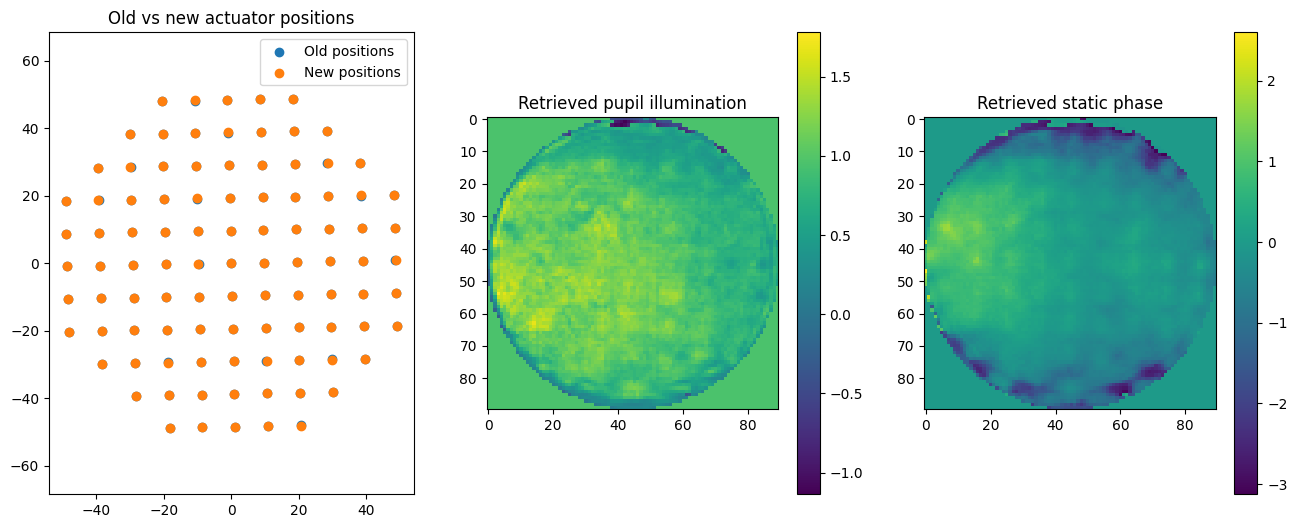

In [41]:
plt.figure(figsize=(16,6))
plt.subplot(131)
plt.title("Old vs new actuator positions")
plt.scatter(original_positons[:,0].cpu().detach(), original_positons[:,1].cpu().detach())
plt.scatter(transformed_positons[:,0].cpu().detach(), transformed_positons[:,1].cpu().detach())
plt.legend(['Old positions', 'New positions'])
plt.axis('equal')
plt.subplot(132)
plt.title('Retrieved pupil illumination')
plt.imshow(ref_pupil.cpu().detach())
plt.colorbar()
plt.subplot(133)
plt.title('Retrieved static phase')
plt.imshow(ref_phase.cpu().detach())
plt.colorbar()

In [42]:
dm.modesComputation()
modes = dm.GetModalModes(M2C)

with torch.no_grad():
    wfs.BuildReconstructionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

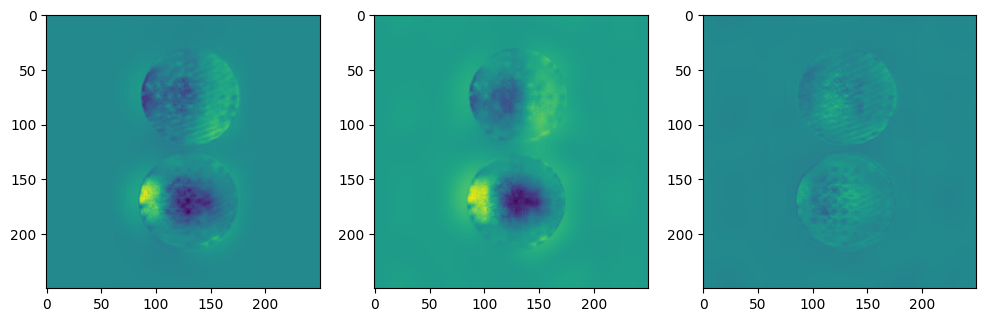

In [52]:
idx = 1
plt.figure(figsize = (12,4))
plt.subplot(131)
plt.imshow((imat_data)[idx].cpu().detach().numpy())
plt.subplot(132)
plt.imshow((wfs.iMat)[idx].cpu().detach().numpy())
plt.subplot(133)
plt.imshow((imat_data[idx] - (wfs.iMat)[idx]).cpu().detach().numpy(), vmin=(imat_data)[idx].cpu().detach().numpy().min(), vmax=(imat_data)[idx].cpu().detach().numpy().max())

C:\Users\foyarzun\Nextcloud\AI4AO\AI4AO\Utils.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


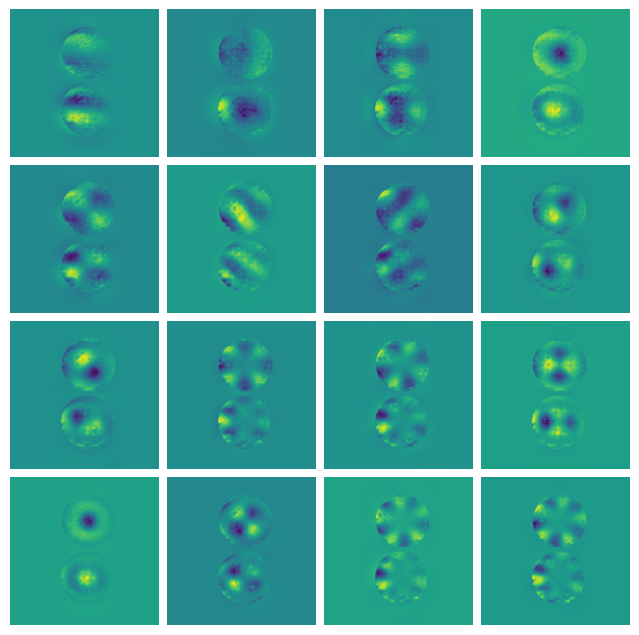

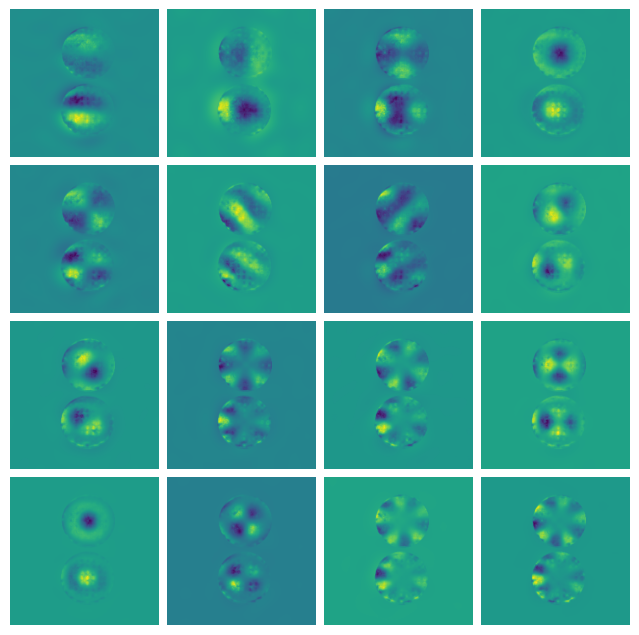

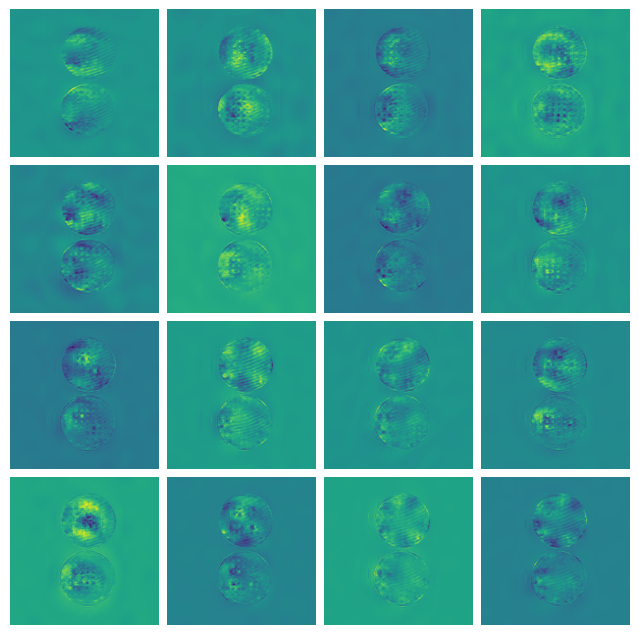

In [51]:
# plt.figure(figsize = (12,4))

imshow(imat_data, max_channel_number=16)
plt.show()
# plt.figure()

imshow(wfs.iMat, max_channel_number=16)
plt.show()

# plt.figure()
imshow(imat_data - wfs.iMat, max_channel_number=16)
plt.show()

In [57]:
with torch.no_grad():
    cov = imat_data.flatten(start_dim = -2) @ wfs.reconstructionMatrix

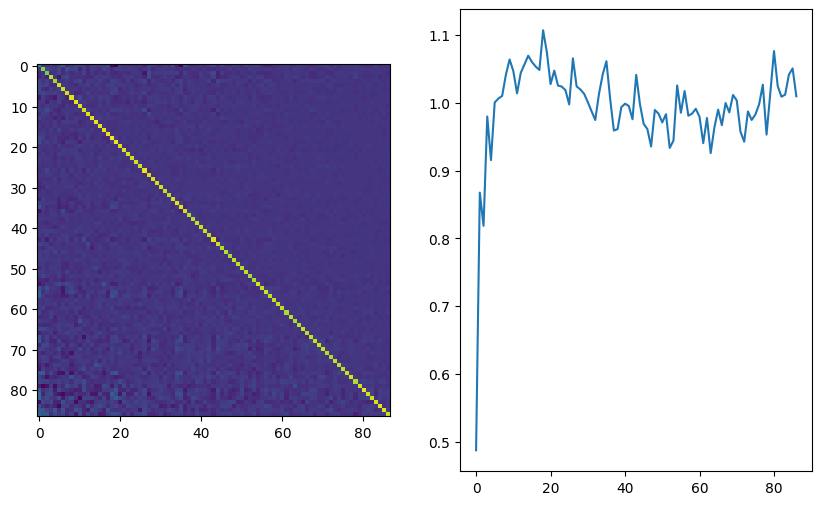

In [58]:
plt.figure(figsize=(10,6))
plt.subplot(121)
plt.imshow(cov.cpu().detach())
plt.subplot(122)
plt.plot(torch.diag(cov).cpu().detach())

In [37]:
misreg, dmdict = dm.GetMisreg()

print(misreg)

print(dmdict)

{'rotationAngle': 91.2120361328125, 'shiftX': 0.007094699541727701, 'shiftY': -0.006167570352554321, 'anamorphosisAngle': -154.16587829589844, 'tangentialScaling': 8.127198368310928, 'radialScaling': 7.377829402685165}
{'moffatParam': 0.9838582277297974, 'signedAmplitude': -1.4117371392785572e-05, 'MechCoupling': 0.20707617700099945, 'FlipLeftRight': True, 'FlipTopBottom': True}


In [6]:
PATH_WFS = "../Data/Oziriis/OziriisWFS.pth"
# torch.save(wfs.state_dict(), PATH_WFS)

PATH_DM = "../Data/Oziriis/OziriisDM.pth"
# torch.save(dm.state_dict(), PATH_DM)

checkpoint = torch.load(PATH_WFS, weights_only=True)
wfs.load_state_dict(checkpoint)

checkpoint = torch.load(PATH_DM, weights_only=True)
dm.load_state_dict(checkpoint)

<All keys matched successfully>

In [7]:
dm.GetMisreg()

({'rotationAngle': 91.2120361328125,
  'shiftX': 0.007094699541727701,
  'shiftY': -0.006167570352554321,
  'anamorphosisAngle': -154.16587829589844,
  'tangentialScaling': 8.127198368310928,
  'radialScaling': 7.377829402685165},
 {'moffatParam': 0.9838582277297974,
  'signedAmplitude': -1.4117371392785572e-05,
  'MechCoupling': 0.20707617700099945,
  'FlipLeftRight': True,
  'FlipTopBottom': True})